In [653]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import binom

# 5

In [654]:
n = 100
teta = 2
x = np.random.uniform(teta, 2*teta, n)

### точный доверительный интервал:

In [655]:
t1_exact = x.max()/((0.975)**(1/n) + 1)
t2_exact = x.max()/((0.025)**(1/n) + 1)

print(f"{t1_exact} < teta < {t2_exact}")

1.978160522144196 < teta < 2.01438736442262


### асимптотический доверительный интервал (ОММ):

In [656]:
a_1 = np.mean(x)
a_2 = np.sum(x**2)/n

In [657]:
t1_as = 2/3 * x.mean() - 3/2 * 1.96 * np.sqrt(a_2 - a_1**2)/np.sqrt(n)
t2_as = 2/3 * x.mean() + 3/2 * 1.96 * np.sqrt(a_2 - a_1**2)/np.sqrt(n)

print(f"{t1_as} < teta < {t2_as}")

1.8649716843489115 < teta < 2.2158130073811684


### бутстрап

In [658]:
def subsample(x, n):
    mask = np.random.randint(0, n, size=n)
    sub_x = x[mask]
    return sub_x

def teta_est(x):
    return 2/3 * np.mean(x)

def bootstrap_mean(x, n, N):
    teta_est_x = teta_est(x)
    delta = np.zeros(N)
    for i in range (0, N):
        sub_x = subsample(x, n)
        delta[i] = teta_est(sub_x) - teta_est_x
    return delta

N = 1000
teta_est_x = teta_est(x)
delta = bootstrap_mean(x, np.size(x), N)

delta_sort = np.sort(delta)
t1_b = teta_est_x - delta_sort[int(0.975 * N)]
t2_b = teta_est_x - delta_sort[int(0.025 * N)]

print(f"{t1_b} < teta < {t2_b}")

1.964073146204448 < teta < 2.1234266859748754


### сравнение

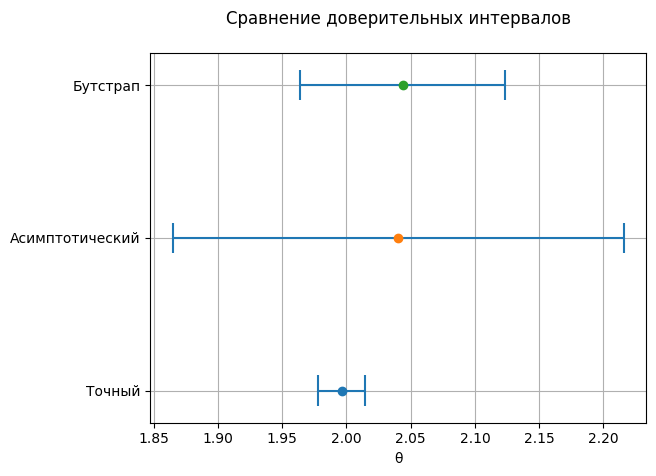

точный l = 0.036226842278423765
асимптотический l = 0.3508413230322569
бутстрап l = 0.15935353977042732


In [659]:
intervals = [
    (t1_exact, t2_exact),
    (t1_as, t2_as),
    (t1_b, t2_b),
]

labels = [
    "Точный",
    "Асимптотический",
    "Бутстрап"
]

centers = [(l + r) / 2 for l, r in intervals]

plt.figure()

for i, ((l, r), c) in enumerate(zip(intervals, centers)):
    plt.hlines(y=i, xmin=l, xmax=r)
    plt.vlines([l, r], i-0.1, i+0.1)
    plt.plot(c, i, 'o')

plt.yticks(range(len(intervals)), labels)
plt.xlabel("θ")
plt.title("Сравнение доверительных интервалов\n")

plt.grid()
plt.show()

print(f"точный l = {t2_exact-t1_exact}")
print(f"асимптотический l = {t2_as-t1_as}")
print(f"бутстрап l = {t2_b-t1_b}")

# 6

In [ ]:
n = 100
teta = 2
x = np.random.pareto(teta-1, n) + 1

Минимум выборки: 1.0225263550537271
Сумма логарифмов: 96.34895560780987
Оценка theta: 2.0378939695729734


### доверительный интервал медианы

In [661]:
x_sorted = np.sort(x)
p = 0.5
q_low = int(binom.ppf(0.025, n, p))
q_high = int(binom.ppf(0.975, n, p))

m1 = x_sorted[(q_low-1)]
m2 = x_sorted[(q_high-1)]

l_med = m2-m1

print(f"{m1} < mediana < {m2}")
print(f"l: {l_med}")

true_median = 2 ** (1 / (teta - 1))
print(f"Теоретическая медиана: {true_median}")

1.7516704753339225 < mediana < 2.310620974287309
l: 0.5589504989533867
Теоретическая медиана: 2.0


###  асимптотический доверительный интервал teta

In [662]:
teta_est_x = 1 + n/np.sum(np.log(x))

t1_as = teta_est_x - 1.96*(teta_est_x - 1)/np.sqrt(n)
t2_as = teta_est_x + 1.96*(teta_est_x - 1)/np.sqrt(n)

print(f"{t1_as} < teta < {t2_as}")

1.8344667515366706 < teta < 2.2413211876092762


### бутстрап непараметрический

In [663]:
def subsample(x, n):
    mask = np.random.randint(0, n, size=n)
    sub_x = x[mask]
    return sub_x

def teta_est(x, n):
    return 1 + n/np.sum(np.log(x))

def bootstrap_mean(x, n, N):
    teta_est_x = teta_est(x, n)
    delta = np.zeros(N)
    for i in range (0, N):
        sub_x = subsample(x, n)
        delta[i] = teta_est(sub_x, n) - teta_est_x
    return delta

N = 1000
teta_est_x = teta_est(x, n)
delta = bootstrap_mean(x, n, N)

delta_sort = np.sort(delta)
t1_nb = teta_est_x - delta_sort[int(0.975 * N)]
t2_nb = teta_est_x - delta_sort[int(0.025 * N)]

print(f"{t1_nb} < teta < {t2_nb}")

1.8348994914807308 < teta < 2.1997466972927042


### параметрический бутстрап

In [664]:
def subsample(teta_est_x, n):
    sub_x = np.random.pareto(teta_est_x-1, n) + 1
    return sub_x

def teta_est(x, n):
    return 1 + n/np.sum(np.log(x))

def bootstrap_mean(x, n, N):
    teta_est_x = teta_est(x, n)
    delta = np.zeros(N)
    for i in range (0, N):
        sub_x = subsample(teta_est_x, n)
        delta[i] = teta_est(sub_x, n) - teta_est_x
    return delta

N = 1000
teta_est_x = teta_est(x, n)
delta = bootstrap_mean(x, n, N)

delta_sort = np.sort(delta)
t1_pb = teta_est_x - delta_sort[int(0.975 * N)]
t2_pb = teta_est_x - delta_sort[int(0.025 * N)]

print(f"{t1_pb} < teta < {t2_pb}")

1.7920272915576843 < teta < 2.214009043872279


### сравнение интервалов teta

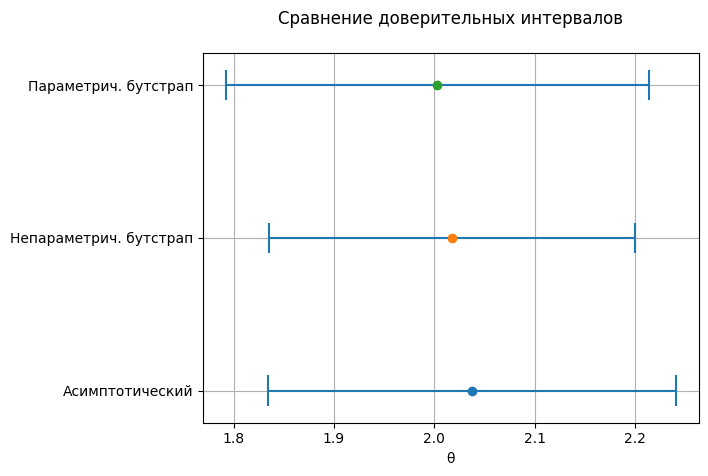

асимптотический l = 0.40685443607260563
непараметрический бутстрап l = 0.3648472058119734
параметрический бутстрап l = 0.4219817523145948


In [665]:
intervals = [
    (t1_as, t2_as),
    (t1_nb, t2_nb),
    (t1_pb, t2_pb),
]

labels = [
    "Асимптотический",
    "Непараметрич. бутстрап",
    "Параметрич. бутстрап"
]

centers = [(l + r) / 2 for l, r in intervals]

plt.figure()

for i, ((l, r), c) in enumerate(zip(intervals, centers)):
    plt.hlines(y=i, xmin=l, xmax=r)
    plt.vlines([l, r], i-0.1, i+0.1)
    plt.plot(c, i, 'o')

plt.yticks(range(len(intervals)), labels)
plt.xlabel("θ")
plt.title("Сравнение доверительных интервалов\n")

plt.grid()
plt.show()

print(f"асимптотический l = {t2_as-t1_as}")
print(f"непараметрический бутстрап l = {t2_nb-t1_nb}")
print(f"параметрический бутстрап l = {t2_pb-t1_pb}")

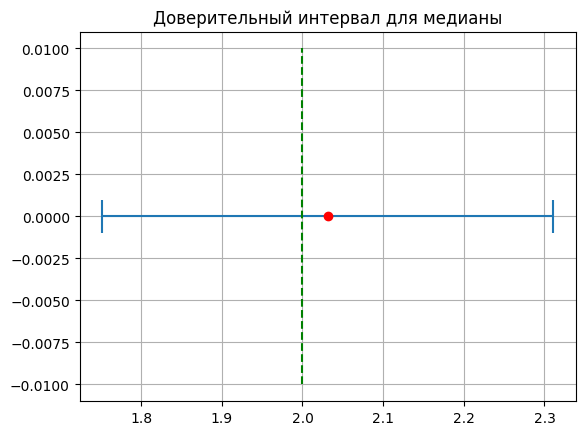

In [666]:
plt.figure()
plt.hlines(y=0, xmin=m1, xmax=m2)
plt.vlines([m1, m2], -0.001, 0.001)
plt.plot((m1 + m2)/2, 0, 'o', color='red')
plt.vlines(true_median, -0.01, 0.01, colors='green', linestyles='dashed')
plt.title("Доверительный интервал для медианы")
plt.grid()
plt.show()